In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

In [8]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

 1. Load Data with Augmentation

In [9]:
from pathlib import Path

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory('../../../data/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse')
val_gen = val_datagen.flow_from_directory('../../../data/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse')

Found 93 images belonging to 5 classes.
Found 25 images belonging to 5 classes.


In [10]:
train_gen.class_indices.keys()

dict_keys(['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling'])

2. Build Model (Transfer Learning)

In [11]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

3. Train and Save

In [12]:
model.fit(train_gen, validation_data=val_gen, epochs=10) # Cambié a 10 epocas para mejorar la precision
model.save('celebrity_model.h5')

/Users/franceliatracygaxiola/Documents/GitHub/IA-Trabajos/.venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 859ms/step - accuracy: 0.2930 - loss: 1.6158 - val_accuracy: 0.2000 - val_loss: 1.8573
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 346ms/step - accuracy: 0.3968 - loss: 1.3223 - val_accuracy: 0.3200 - val_loss: 1.6015
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step - accuracy: 0.6552 - loss: 1.0727 - val_accuracy: 0.4800 - val_loss: 1.3900
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - accuracy: 0.7237 - loss: 0.8285 - val_accuracy: 0.4800 - val_loss: 1.2331
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - accuracy: 0.8768 - loss: 0.6557 - val_accuracy: 0.5200 - val_loss: 1.0947
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - accuracy: 0.8061 - loss: 0.6450 - val_accuracy: 0.5200 - val_loss: 0.9977
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step - accuracy: 0.9012 - loss: 0.5290 - val_accuracy: 0.6000 - val_loss: 0.9265
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step - accuracy: 0.8850 - loss: 0.4191 - val_accuracy: 0.6400 - val_loss:

Store class names for prediction

In [13]:
class_names = list(train_gen.class_indices.keys())
print("Classes identified:", class_names)

Classes identified: ['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling']


Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 787ms/step


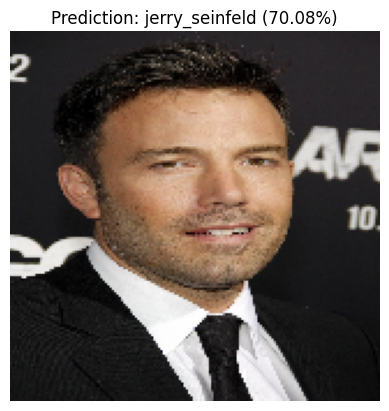

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step


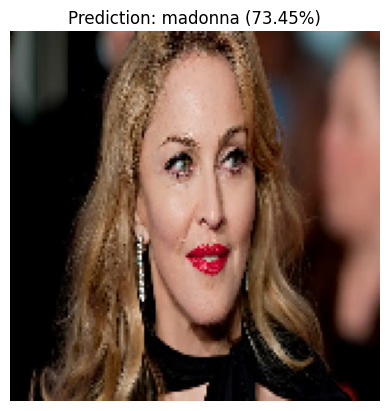

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step


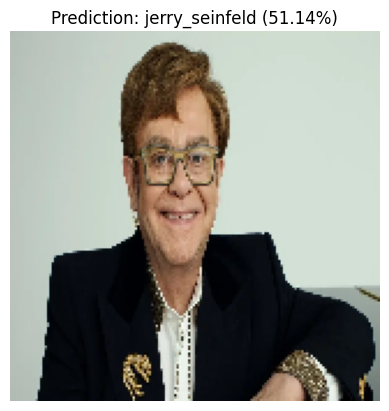

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step


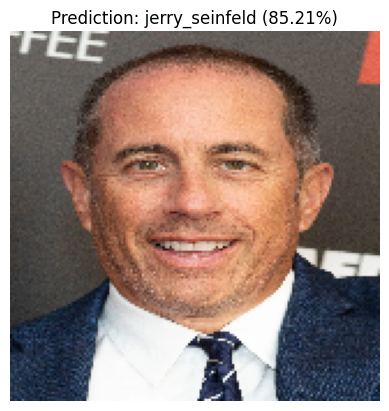

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step


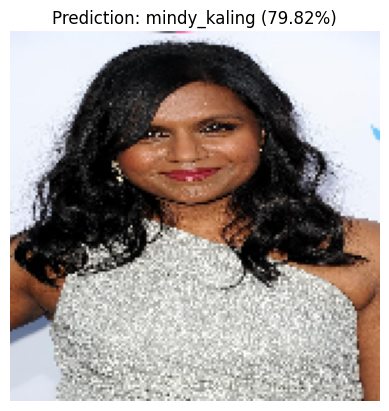

In [14]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_celebrity(img_path, model_path='celebrity_model.h5'):
    # Load model and image
    model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=(160, 160))
    
    # Pre-process
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0) # Create batch axis

    # Predict
    predictions = model.predict(img_array)
    score = np.max(predictions)
    class_idx = np.argmax(predictions)
    
    # Display
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]} ({100 * score:.2f}%)")
    plt.axis('off')
    plt.show()

# Usage:
predict_celebrity('Ben-Affleck.webp')
predict_celebrity('Madonna.webp')
predict_celebrity('Elton-John.webp')
predict_celebrity('Jerry-Seinfeld.webp')
predict_celebrity('Mindy-Kaling.jpg')